# Own-degree vs mean-degree $(C\propto N)$: a controlled comparison

## The model

The relative (scale-invariant) generalized Lotka–Volterra model. In absolute abundances,

$$\dot x_i \;=\; x_i\!\left[\,1 - \frac{x_i}{m} - \frac{(\alpha x)_i}{m}\,\right],
\qquad m \equiv \langle x\rangle = \frac{1}{N}\sum_i x_i .$$

Interactions act on the *mean* firm $m$, so the competition term is $O(M)$ not $O(M^2)$: the
aggregate $M=\sum_i x_i$ grows exponentially with no finite-time blow-up. Separating scale from
shape with the shares $w_i = x_i/M$ $\left(\sum_i w_i = 1\right)$ and the **relative size**
$S_i \equiv N w_i$ (so $\langle S\rangle = 1$ by construction), the shares obey a replicator
equation and the idiosyncratic growth rate is

$$g_i \;\equiv\; \frac{d\ln S_i}{dt}
\;=\; \underbrace{1 - S_i}_{\text{self-limitation}}
\;-\; \underbrace{(\alpha S)_i}_{\text{interaction field }h_i}
\;-\; \langle f\rangle .$$

The common growth $\langle f\rangle$ cancels in $g_i$, so $g_i$ is the firm's growth *net of the
economy* — exactly what firm-growth data measure. The volatility is a fat-tail-robust estimator

$$\sigma_i \;=\; \sqrt{\tfrac{\pi}{2}}\;\big\langle\, \lvert g_i - \langle g_i\rangle\rvert \,\big\rangle_t
\qquad(\text{MAD}=\text{std for a Gaussian, but robust to the tent tails}).$$

## Two normalizations of the disorder

Both models live on the *same* power-law graph $P(k)\sim k^{-2.5}$ (configuration model, degrees
$k_i$); they differ only in how each coupling is scaled:

$$\textbf{own-degree:}\quad \alpha_{ij} = \frac{\mu}{k_i} + \frac{\sigma}{\sqrt{k_i}}\,z_{ij},
\qquad\qquad
\textbf{mean-degree:}\quad \alpha_{ij} = \frac{\mu}{C} + \frac{\sigma}{\sqrt{C}}\,z_{ij},$$

with $z_{ij}\sim\mathcal N(0,1)$ i.i.d. and $C=\langle k\rangle$. The disorder field
$h_i=\sum_{j}\alpha_{ij}S_j$ each firm feels then has variance

$$\underbrace{\mathrm{Var}[h_i]\approx \sigma^2\langle S^2\rangle}_{\text{own-degree: degree-independent}}
\qquad\text{vs}\qquad
\underbrace{\mathrm{Var}[h_i]\approx \sigma^2\,\frac{k_i}{C}\,\langle S^2\rangle}_{\text{mean-degree: }\propto\,k_i} .$$

The $1/\sqrt{k_i}$ of own-degree cancels the $\sqrt{k_i}$ of the neighbour sum, quieting *every* firm
to a common forcing; mean-degree lets a hub feel a field $\propto$ its degree.

## Why mean-degree needs $C\propto N$

On the $P(k)\sim k^{-2.5}$ graph the largest hub saturates at $k_{\max}=N-1$, so the worst
over-coupling is $k_{\max}/C = N/C$. Holding it fixed as $N\to\infty$ forces

$$\boxed{\,C \;\propto\; N\,}.$$

Own-degree has no such pathology — $\mathrm{Var}[h_i]$ is degree-free — so its $\beta$ is $N$-stable at
*fixed* $C$. We therefore run **own-degree at fixed $C$** and **mean-degree at $C(N)=C_0\,N/N_0$**,
each in its proper configuration.

## What we compare
$$\sigma(\bar S)\sim \bar S^{-\beta}\ \ (\zeta_1=\beta), \quad
E[\sigma^q\!\mid\! S]\sim S^{-\zeta_q}\ \text{(multiscaling)}, \quad
P(g)\ \text{(growth tent)}, \quad
P_{\rm surv}(N), \quad \sigma_i(k_i).$$

In [1]:
import os, sys, time
while not os.path.isdir("relative_glv") and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")                                          # run from repo root OR notebooks/
sys.path.insert(0, os.getcwd())
import numpy as np
from scipy.stats import laplace
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from relative_glv.model import coupling, integrate
from relative_glv.msb import size_volatility, tent_stats, rescale

SMOKE = os.environ.get("CMP_SMOKE", "0") == "1"
MU, SIGMA, LAM = 1.76, 1.75, 1e-3
N0, C0 = 4000, 100
C_OWN = 100                                     # own-degree: fixed C (N-robust)
def C_mean(N): return max(2, round(C0 * N / N0))  # mean-degree: C ∝ N
MODELS = {"own-degree": "powerlaw_owndeg", "mean-degree (C∝N)": "powerlaw"}
COL = {"own-degree": "#2a9d8f", "mean-degree (C∝N)": "#e76f51"}
NS = [1000, 2000] if SMOKE else [2000, 4000, 8000, 16000]
N_REP = 2000 if SMOKE else 8000                 # N for the detailed pooled comparisons
SEED_SURV = 2 if SMOKE else 12
SEED_DET = 3 if SMOKE else 16
TMAX, N_EVAL = (100.0, 400) if SMOKE else (250.0, 700)
LATE, DT = ((75.0, 98.0) if SMOKE else (180.0, 240.0)), 0.5
NB, NJOBS = 20, 6
print(f"{'SMOKE ' if SMOKE else ''}own(C={C_OWN}) vs mean(C∝N)  NS={NS}  N_rep={N_REP} "
      f"(mean C={C_mean(N_REP)})  surv_seeds={SEED_SURV} det_seeds={SEED_DET}  window={LATE}")

own(C=100) vs mean(C∝N)  NS=[2000, 4000, 8000, 16000]  N_rep=8000 (mean C=200)  surv_seeds=12 det_seeds=16  window=(180.0, 240.0)


In [2]:
def simulate(model, N, seed, heavy=False):
    """One economy. Returns survival info always; if heavy & alive, also per-firm Sbar/vol/growth/k.
    survived := integration ok, >=50 firms above floor, and still FLUCTUATING (median vol not ~0)."""
    kind = MODELS[model]
    C = C_OWN if model == "own-degree" else C_mean(N)
    dead = dict(model=model, N=N, seed=seed, survived=False, n_surv=0, beta=np.nan)
    try:
        a = coupling(N, MU, SIGMA, kind=kind, seed=seed, mean_degree=C)
        r = integrate(a, tmax=TMAX, n_eval=N_EVAL, lam=LAM, seed=seed,
                      method="RK45", rtol=1e-4, atol=1e-7)
        if not r["success"]:
            return dead
        win = (r["t"] >= LATE[0]) & (r["t"] <= LATE[1])
        live = r["W"][:, win].min(1) > 1e-6
        n_surv = int(live.sum())
        if n_surv < 50:
            return {**dead, "n_surv": n_surv}                 # condensed / mass extinction
        sv = size_volatility(r["W"], r["t"], window=LATE, dt=DT, n_bins=NB)
        med_vol = float(np.median(sv["vol"])) if sv["vol"].size else 0.0
        alive = bool(np.isfinite(sv["beta"]) and med_vol > 1e-2)   # not frozen onto a fixed point
        rec = dict(model=model, N=N, seed=seed, survived=alive, n_surv=n_surv,
                   beta=float(sv["beta"]) if np.isfinite(sv["beta"]) else np.nan)
        if heavy and alive:
            k = np.diff(a.indptr).astype(float)
            rec.update(Sbar=sv["Sbar"], vol=sv["vol"], growth=sv["growth"], k=k[live])
        return rec
    except Exception:
        return dead

t0 = time.time()
surv_jobs = [(m, N, s) for m in MODELS for N in NS for s in range(SEED_SURV)]
surv = Parallel(n_jobs=NJOBS, backend="loky")(delayed(simulate)(m, N, s) for m, N, s in surv_jobs)
det_jobs = [(m, N_REP, s) for m in MODELS for s in range(SEED_DET)]
det = Parallel(n_jobs=NJOBS, backend="loky")(delayed(simulate)(m, N_REP, s, True) for m, N, s in det_jobs)
print(f"integrated {len(surv)+len(det)} economies in {(time.time()-t0)/60:.1f} min")

/Users/ludovicofurlanetto/Code/relative-glv/.venv/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


integrated 128 economies in 21.2 min


In [3]:
def multiscaling(Sbar, vol, econ, nb=NB, nboot=300):
    live = (vol > 0) & np.isfinite(vol) & (Sbar > 0); Sbar, vol, econ = Sbar[live], vol[live], econ[live]
    o = np.argsort(Sbar); P = np.array_split(np.arange(o.size), nb)
    bx = np.array([Sbar[o][p].mean() for p in P]); by = np.array([np.median(vol[o][p]) for p in P])
    m = (bx > 0) & (by > 0); bx, by = bx[m], by[m]; pk = int(np.argmax(by)); dec = Sbar > bx[pk]
    nfit = max(6, nb - pk)
    def cq_of(Sx, vx):
        ox = np.argsort(Sx); Px = np.array_split(np.arange(ox.size), nfit)
        bxx = np.array([Sx[ox][p].mean() for p in Px]); out = []
        for q in (1, 2, 3, 4):
            byy = np.array([np.mean(vx[ox][p] ** q) for p in Px]); mm = (bxx > 0) & (byy > 0)
            out.append(-np.polyfit(np.log10(bxx[mm]), np.log10(byy[mm]), 1)[0])
        return np.array(out)
    cq = cq_of(Sbar[dec], vol[dec])
    ue = np.unique(econ[dec]); rbs = np.random.default_rng(0); boot = []
    for _ in range(nboot):
        pick = rbs.choice(ue, ue.size, replace=True)
        ix = np.concatenate([np.where(econ[dec] == e)[0] for e in pick])
        boot.append(cq_of(Sbar[dec][ix], vol[dec][ix]))
    boot = np.array(boot)
    return dict(cq=cq, ratio=cq / cq[0], ratio_err=(boot / boot[:, [0]]).std(0),
                bin_S=bx, bin_vol=by)

def binmed(x, y, nb=18):
    o = np.argsort(x); P = np.array_split(np.arange(o.size), nb)
    bx = np.array([x[o][p].mean() for p in P]); by = np.array([np.median(y[o][p]) for p in P])
    m = (bx > 0) & (by > 0); return bx[m], by[m]

# ---- aggregate detailed (pooled) per model ----
D = {}
for model in MODELS:
    recs = [x for x in det if x["model"] == model and x.get("survived") and "Sbar" in x]
    if not recs:
        print(f"{model}: no survivors at N_rep"); continue
    Sbar = np.concatenate([x["Sbar"] for x in recs]); vol = np.concatenate([x["vol"] for x in recs])
    growth = np.vstack([x["growth"] for x in recs]); kk = np.concatenate([x["k"] for x in recs])
    econ = np.concatenate([np.full(x["Sbar"].size, i) for i, x in enumerate(recs)])
    ms = multiscaling(Sbar, vol, econ); ts = tent_stats(growth)
    kx, sk = binmed(kk[np.isfinite(vol) & (vol > 0)], vol[np.isfinite(vol) & (vol > 0)])
    slope = float(np.polyfit(np.log10(kx), np.log10(sk), 1)[0])
    D[model] = dict(ms=ms, ts=ts, gz=rescale(growth), kx=kx, sk=sk, kslope=slope,
                    n=len(recs), nf=Sbar.size)

# ---- survival fraction per (model, N) ----
SURV = {m: {N: np.mean([x["survived"] for x in surv if x["model"] == m and x["N"] == N]) for N in NS}
        for m in MODELS}

print(f"{'model':<20}{'econ':>5}{'firms':>7}{'beta':>7}{'z2':>6}{'z3':>6}{'z4':>6}"
      f"{'z4/z1':>7}{'exk':>7}{'sig~k':>8}")
for m in MODELS:
    if m not in D: continue
    c = D[m]["ms"]["cq"]
    print(f"{m:<20}{D[m]['n']:>5}{D[m]['nf']:>7}{c[0]:>7.2f}{c[1]:>6.2f}{c[2]:>6.2f}{c[3]:>6.2f}"
          f"{D[m]['ms']['ratio'][3]:>7.2f}{D[m]['ts']['exkurt']:>7.1f}{D[m]['kslope']:>+8.2f}")
print("\nsurvival fraction P_surv(N):")
for m in MODELS:
    print(f"  {m:<20} " + "  ".join(f"N={N}:{SURV[m][N]:.2f}" for N in NS))

model                econ  firms   beta    z2    z3    z4  z4/z1    exk   sig~k
own-degree             16  31149   0.70  1.31  1.79  2.14   3.07   16.7   +0.00
mean-degree (C∝N)      16  20949   0.34  0.52  0.61  0.62   1.85   12.5   +0.13

survival fraction P_surv(N):
  own-degree           N=2000:0.83  N=4000:0.83  N=8000:1.00  N=16000:0.83
  mean-degree (C∝N)    N=2000:0.33  N=4000:1.00  N=8000:1.00  N=16000:1.00


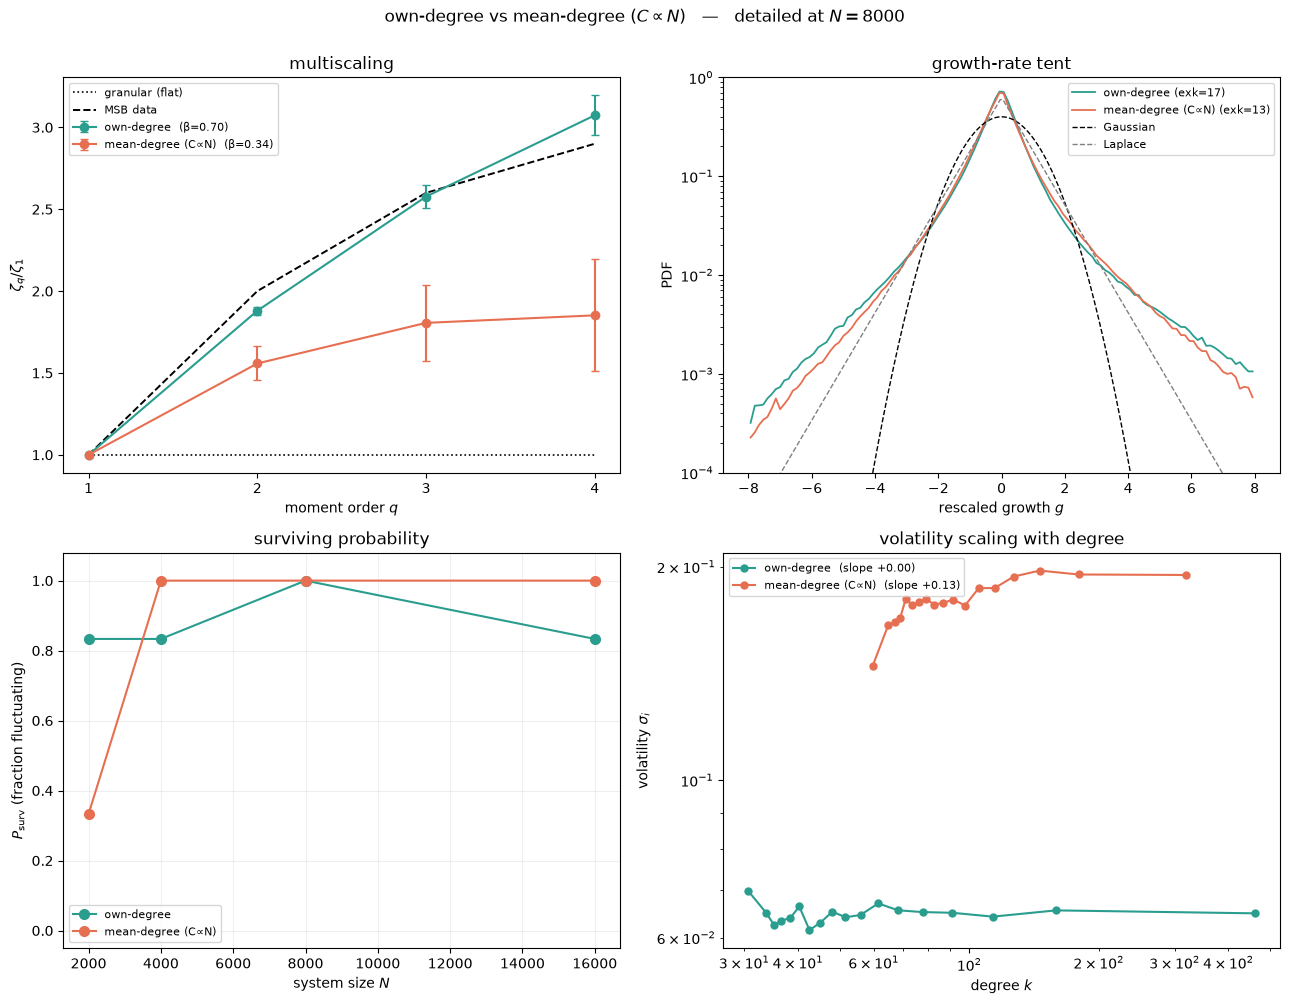

In [4]:
qs = np.array([1, 2, 3, 4])
fig, ax = plt.subplots(2, 2, figsize=(13, 10))

# (0,0) multiscaling ratios
for m in MODELS:
    if m not in D: continue
    ms = D[m]["ms"]
    ax[0, 0].errorbar(qs, ms["ratio"], yerr=ms["ratio_err"], marker="o", ms=6, capsize=3,
                      color=COL[m], label=f"{m}  (β={ms['cq'][0]:.2f})")
ax[0, 0].plot(qs, [1, 1, 1, 1], "k:", lw=1.2, label="granular (flat)")
ax[0, 0].plot(qs, [1, 2.0, 2.6, 2.9], "k--", lw=1.4, label="MSB data")
ax[0, 0].set(xlabel="moment order $q$", ylabel=r"$\zeta_q/\zeta_1$", xticks=qs, title="multiscaling")
ax[0, 0].legend(fontsize=8)

# (0,1) growth tent
zz = np.linspace(-8, 8, 200)
for m in MODELS:
    if m not in D: continue
    h, e = np.histogram(D[m]["gz"], bins=120, range=(-8, 8), density=True); mm = h > 0
    ax[0, 1].semilogy(0.5 * (e[:-1] + e[1:])[mm], h[mm], lw=1.3, color=COL[m],
                      label=f"{m} (exk={D[m]['ts']['exkurt']:.0f})")
ax[0, 1].semilogy(zz, np.exp(-zz ** 2 / 2) / np.sqrt(2 * np.pi), "k--", lw=1, label="Gaussian")
ax[0, 1].semilogy(zz, laplace.pdf(zz, scale=np.sqrt(2 / np.pi)), "0.5", ls="--", lw=1, label="Laplace")
ax[0, 1].set(xlabel=r"rescaled growth $g$", ylabel="PDF", ylim=(1e-4, 1), title="growth-rate tent")
ax[0, 1].legend(fontsize=8)

# (1,0) survival probability vs N
for m in MODELS:
    ax[1, 0].plot(NS, [SURV[m][N] for N in NS], "o-", ms=7, color=COL[m], label=m)
ax[1, 0].set(xlabel="system size $N$", ylabel=r"$P_{\rm surv}$ (fraction fluctuating)",
             ylim=(-0.05, 1.08), title="surviving probability")
ax[1, 0].legend(fontsize=8); ax[1, 0].grid(alpha=0.2)

# (1,1) volatility vs degree
for m in MODELS:
    if m not in D: continue
    ax[1, 1].loglog(D[m]["kx"], D[m]["sk"], "o-", ms=5, color=COL[m],
                    label=f"{m}  (slope {D[m]['kslope']:+.2f})")
ax[1, 1].set(xlabel=r"degree $k$", ylabel=r"volatility $\sigma_i$", title="volatility scaling with degree")
ax[1, 1].legend(fontsize=8)

fig.suptitle(f"own-degree vs mean-degree ($C\\propto N$)   —   detailed at $N={N_REP}$", y=1.00)
plt.tight_layout()
plt.savefig("data/own_vs_mean.png", dpi=120)
plt.show()

In [5]:
save = {"NS": np.array(NS), "N_rep": N_REP}
for m in MODELS:
    tag = "own" if "own" in m else "mean"
    save[f"{tag}_surv"] = np.array([SURV[m][N] for N in NS])
    if m in D:
        save[f"{tag}_cq"] = D[m]["ms"]["cq"]; save[f"{tag}_ratio"] = D[m]["ms"]["ratio"]
        save[f"{tag}_ratio_err"] = D[m]["ms"]["ratio_err"]; save[f"{tag}_kslope"] = D[m]["kslope"]
        save[f"{tag}_exk"] = D[m]["ts"]["exkurt"]; save[f"{tag}_gz"] = D[m]["gz"][::max(1, D[m]["gz"].size//40000)].astype(np.float32)
        save[f"{tag}_kx"] = D[m]["kx"]; save[f"{tag}_sk"] = D[m]["sk"]
np.savez("data/own_vs_mean.npz", **save)
print("saved data/own_vs_mean.npz and data/own_vs_mean.png")

saved data/own_vs_mean.npz and data/own_vs_mean.png


## Reading the comparison

- **Multiscaling** $\zeta_q/\zeta_1$: both rise above the flat granular line, but this is the one
  observable where the two normalizations *should* differ — own-degree's per-firm quieting builds the
  size-growing correlations; mean-degree's uniform scaling builds fewer. **Caveat (measured this
  session):** $\zeta_4/\zeta_1$ is not robustly pinned — it drifts with $N$/sample size — so read the
  *shape* of the comparison, not the exact numbers against MSB.
- **Growth tent**: both are fat-tailed and symmetric (Bowley $\approx 0$); compare their excess
  kurtosis.
- **Surviving probability** $P_{\rm surv}(N)$: fraction of economies that stay in the fluctuating state
  (not frozen, not condensed). Own-degree's persistence strengthens with $N$; whether mean-degree at
  $C\propto N$ keeps pace tests whether the super-hub still destabilizes it.
- **Volatility vs degree** $\sigma_i(k_i)$ is the cleanest signature of the normalization: own-degree
  should be **flat** (degree quieted out, $\mathrm{Var}[h_i]$ degree-free), mean-degree should **rise**
  with $k$ ($\mathrm{Var}[h_i]\propto k_i$, hubs louder). This single panel *is* the difference between
  the two models, made visible.